stock price prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# ----------------------------------------------------------
# 1. LOAD DATA

df = pd.read_csv("product_monthly_panel.csv")

# Use 'rating' column as time series target
ratings = df['rating'].dropna().values.reshape(-1, 1).astype(np.float32)

# 2. SCALE DATA

scaler = MinMaxScaler()
ratings_scaled = scaler.fit_transform(ratings)


# 3. CREATE SEQUENCES

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 7  # using 7 past steps to predict next
X, y = create_sequences(ratings_scaled, seq_length)


In [2]:
# 4. TRAIN-TEST SPLIT

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Reshape input to (batch_size, sequence_length, num_features)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)


In [3]:
# 5. DEFINE LSTM MODEL

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # only final timestep
        return out

model = LSTMRegressor()


In [4]:
# 6. TRAINING SETUP
# ----------------------------------------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [5]:
# 7. TRAIN THE MODEL

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        output = model(batch_x)
        loss = criterion(output, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {running_loss / len(train_loader):.4f}")


Epoch 1/20, Avg Loss: 0.0565
Epoch 2/20, Avg Loss: 0.0513
Epoch 3/20, Avg Loss: 0.0514
Epoch 4/20, Avg Loss: 0.0512
Epoch 5/20, Avg Loss: 0.0513
Epoch 6/20, Avg Loss: 0.0512
Epoch 7/20, Avg Loss: 0.0511
Epoch 8/20, Avg Loss: 0.0510
Epoch 9/20, Avg Loss: 0.0510
Epoch 10/20, Avg Loss: 0.0510
Epoch 11/20, Avg Loss: 0.0509
Epoch 12/20, Avg Loss: 0.0509
Epoch 13/20, Avg Loss: 0.0508
Epoch 14/20, Avg Loss: 0.0508
Epoch 15/20, Avg Loss: 0.0507
Epoch 16/20, Avg Loss: 0.0507
Epoch 17/20, Avg Loss: 0.0507
Epoch 18/20, Avg Loss: 0.0507
Epoch 19/20, Avg Loss: 0.0506
Epoch 20/20, Avg Loss: 0.0506


In [6]:
# 8. EVALUATION
# ----------------------------------------------------------
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).numpy()
    y_test_np = y_test_t.numpy()

# Inverse transform predictions back to original scale
y_pred_original = scaler.inverse_transform(y_pred)
y_test_original = scaler.inverse_transform(y_test_np)


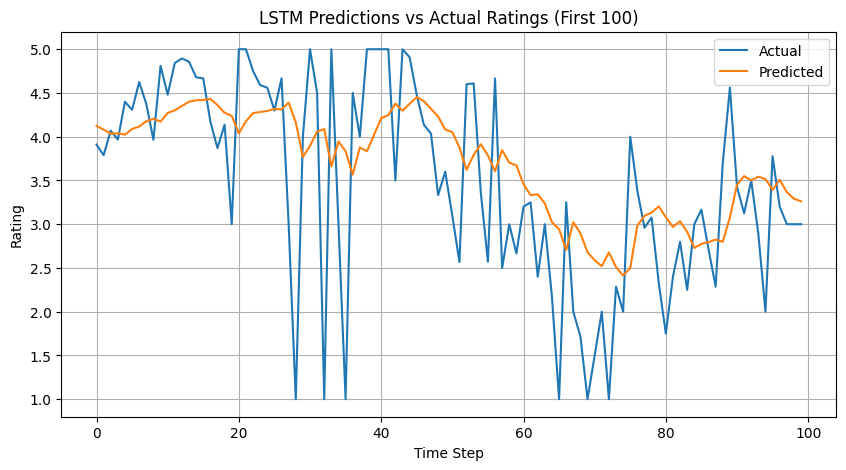

In [7]:
# 9. PLOT RESULTS
# ----------------------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test_original[:100], label='Actual')
plt.plot(y_pred_original[:100], label='Predicted')
plt.title('LSTM Predictions vs Actual Ratings (First 100)')
plt.xlabel('Time Step')
plt.ylabel('Rating')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# 10. METRICS
# ----------------------------------------------------------
mse = np.mean((y_pred_original - y_test_original) ** 2)
rmse = np.sqrt(mse)
print(f"\nTest MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")



Test MSE: 0.8996
Test RMSE: 0.9485
